In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

In [39]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["chemprop"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-04-28 21:25:36.613 | INFO     | src.datasets:load:865 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-28 21:25:36.987 | INFO     | src.datasets:_sample_qm9_df:1065 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-28 21:25:36.987 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-28 21:25:36.988 | INFO     | src.features:compute_chemprop_embeddings:686 - Computing Chemprop embeddings on mps...
2026-04-28 21:25:36.988 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-04-28 21:25:36.989 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-04-28 21:25:37.032 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-04-28 21:25:37.036 | INFO  

In [4]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,chemprop_embedding
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,"array[f32, 2048]"
"""qm9_955""","""C4H6N2O""","""[H]OC1=C(N([H])[H])C([H])=C([H…","""[H]Oc1c(N([H])[H])c([H])c([H])…","""c1cc[nH]c1""","""C1CCCC1""","""*1:*:*:*:*:1""","""[5*]N([H])[H],[14*]c1c([16*])c…","""[H]Oc1c(N([H])[H])c([H])c([H])…","""[H][O][C][=C][Branch1][=Branch…","""phenol,amine""","""Aromatic""",0,null,98,0,62,0.633443,13.024467,7,1,1,0,3,13,2.0,2,0.0,1.0,0.0,3,2,6,0,4,0,5,23,1.227029,0,0,1,1,0,0,0,0,0,0,"[[-0.2178, 1.4284, -0.0455], [-0.0129, 0.0148, -0.0123], … [2.1804, -0.4568, 0.1775]]","[7, 6, … 1]",0.4919,55.52,-4.772877,1.736086,6.508964,662.223328,2.827426,-9269.803711,-9269.626953,-9269.601562,-9270.614258,24.818001,-55.455803,-55.780842,-56.089256,-51.719322,3.93123,3.24201,1.79361,"[0.154452, 0.025816, … 0.0]"
"""qm9_1736""","""C7H14""","""[H]C([H])([H])C([H])([H])[C@@]…","""[H]C([H])([H])C([H])([H])[C@@]…","""C1CC1""","""C1CC1""","""*1**1""","""[8*]C([H])([H])[H],[15*]C1([15…","""[H]C([H])([H])C([H])([H])[C@@]…","""[H][C][Branch1][C][H][Branch1]…","""""","""Aliphatic Ring""",0,null,98,2,0,0.923503,12.819052,7,1,0,0,0,21,2.0,4,0.0,0.0,1.0,0,0,7,0,0,7,6,47,1.243056,0,0,0,0,0,0,0,0,0,0,"[[0.2213, 1.5233, 0.2337], [-0.1784, 0.0907, -0.1463], … [0.9584, -3.9143, -0.4297]]","[6, 6, … 1]",0.1214,74.82,-6.944345,2.378275,9.32262,912.392883,5.263661,-7482.745117,-7482.504883,-7482.479004,-7483.631836,32.778999,-83.119087,-83.688652,-84.202789,-77.177216,3.57463,1.93782,1.60298,"[0.035807, 0.041797, … 0.0]"
"""qm9_1936""","""C4H8N2O""","""[H]N([H])C(=O)C([H])([H])[C@]1…","""[H]N([H])C(=O)C([H])([H])[C@]1…","""C1CN1""","""C1CC1""","""*1**1""","""[5*]N([H])[H],[1*]C(=O)C([8*])…","""[H]N([H])C(=O)C([H])([H])[C@]1…","""[H][N][Branch1][C][H][C][=Bran…","""amine,amide""","""Aliphatic Ring""",0,null,100,-1,65,0.649543,13.100996,7,1,0,0,3,15,2.0,2,0.0,0.25,0.75,2,2,6,0,1,3,6,31,1.250597,0,0,0,1,1,0,0,0,0,0,"[[0.1422, 0.1826, -1.0035], [-0.0036, 0.0299, 0.3438], … [-2.4739, -1.282, -1.2223]]","[7, 6, … 1]",2.5886,57.330002,-6.593319,0.848995,7.442314,854.169189,3.428253,-9301.972656,-9301.772461,-9301.746094,-9302.838867,26.408001,-60.398857,-60.7771,-61.136917,-56.138103,6.66628,1.60444,1.37235,"[0.044777, 0.0, … 0.0]"
"""qm9_4368""","""C5H7NO2""","""[H]OC1=C([H])C(C([H])([H])[H])…","""[H]Oc1oc(N([H])[H])c(C([H])([H…","""c1ccoc1""","""C1CCCC1""","""*1:*:*:*:*:1""","""[5*]N([H])[H],[14*]c1oc([14*])…","""[H]Oc1oc(N([H])[H])c(C([H])([H…","""[H][O][C][O][C][Branch1][=Bran…","""phenol,amine""","""Aromatic""",0,null,113,0,59,0.874146,12.884048,8,1,1,0,3,15,2.0,3,0.0,0.8,0.2,2,3,6,0,4,1,6,27,1.242324,0,0,1,1,0,0,0,0,0,0,"[[0.0654, 1.5524, 0.0794], [0.0385, 0.0575, 0.0588], … [0.1176, -0.5619, 2.243]]","[6, 6, … 1]",1.872,64.709999,-5.104856,1.115667,6.217802,964.561096,3.220005,-10879.922852,-10879.702148,-10879.676758,-10880.794922,29.877001,-64.790375,-65.147896,-65.507721,-60.431732,3.61567,1.75424,1.19755,"[0.120097, 0.0, … 0.0]"
"""qm9_5229""","""C7H9N""","""

In [5]:
for i in range(1000):
    if int(df['num_atoms'].to_list()[i]) != int(len(df['coordinates'].to_list()[i])):
        print(df['mol_id'].to_list()[i])
        break

qm9_12007


In [6]:
k=16
df['mol_id'].to_list()[k], df['num_atoms'].to_list()[k], len(df['coordinates'].to_list()[k])

('qm9_13663', 18, 18)

In [7]:
len(molecules[0:2])

2

In [8]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [41]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="chemprop",
    dist_type="euclidean",
    force_calculate=True,
    pca_components=50
)

2026-04-28 21:26:11.395 | INFO     | src.datasets:get_distance_matrix:1472 - Applying PCA to reduce 'chemprop' to 50 dimensions.
2026-04-28 21:26:11.560 | INFO     | src.datasets:get_distance_matrix:1476 - PCA kept 72.73% of the variance for 'chemprop'.
2026-04-28 21:26:11.560 | INFO     | src.datasets:get_distance_matrix:1478 - PCA reduced 'chemprop' dimensions from 2048 to 50
2026-04-28 21:26:11.584 | INFO     | src.datasets:get_distance_matrix:1493 - Calculating distance matrix for chemprop using euclidean distance.
2026-04-28 21:26:11.881 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_chemprop_euclidean_pca50.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:00<00:00, 229.09it/s]


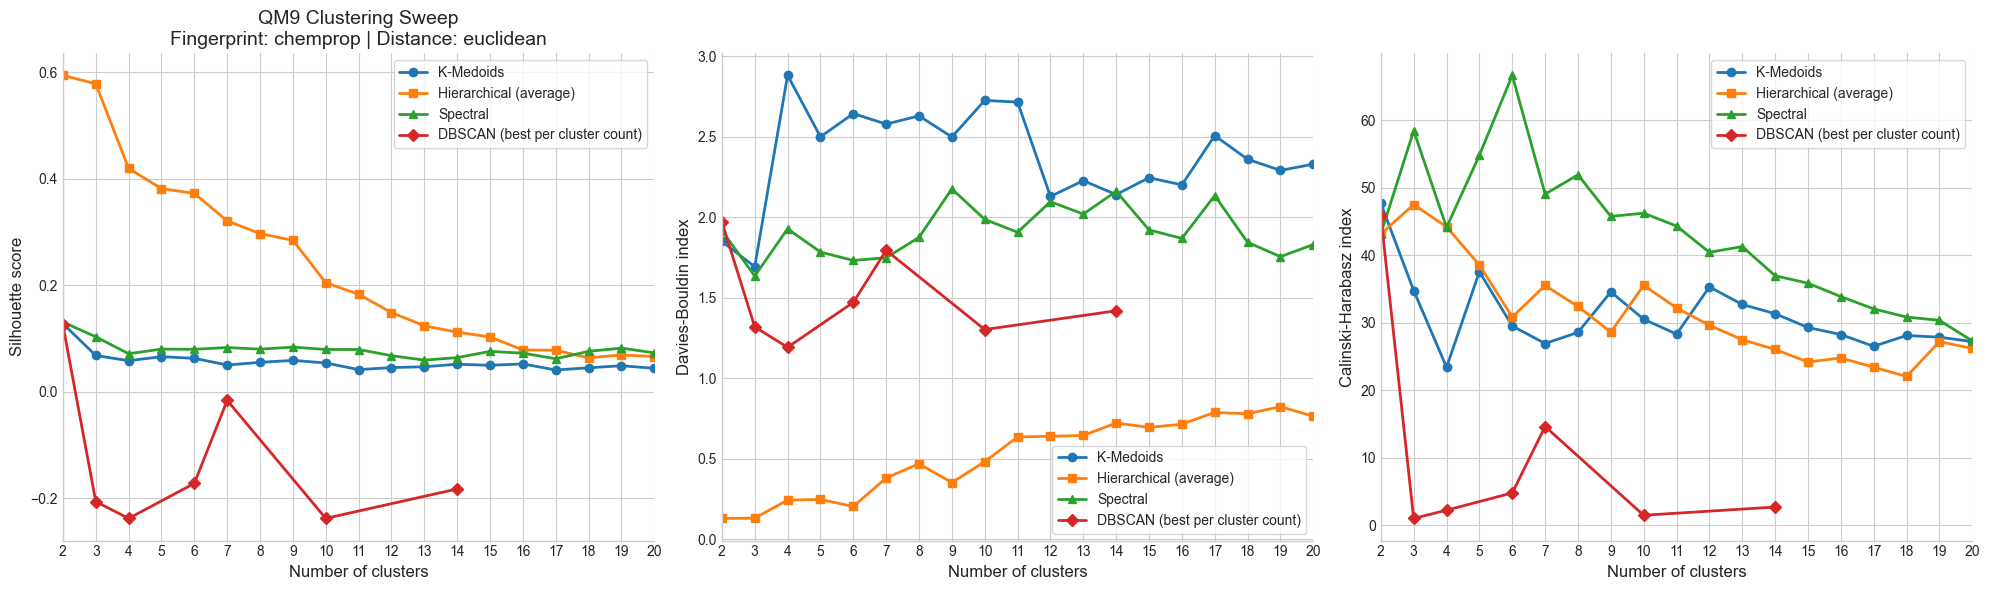

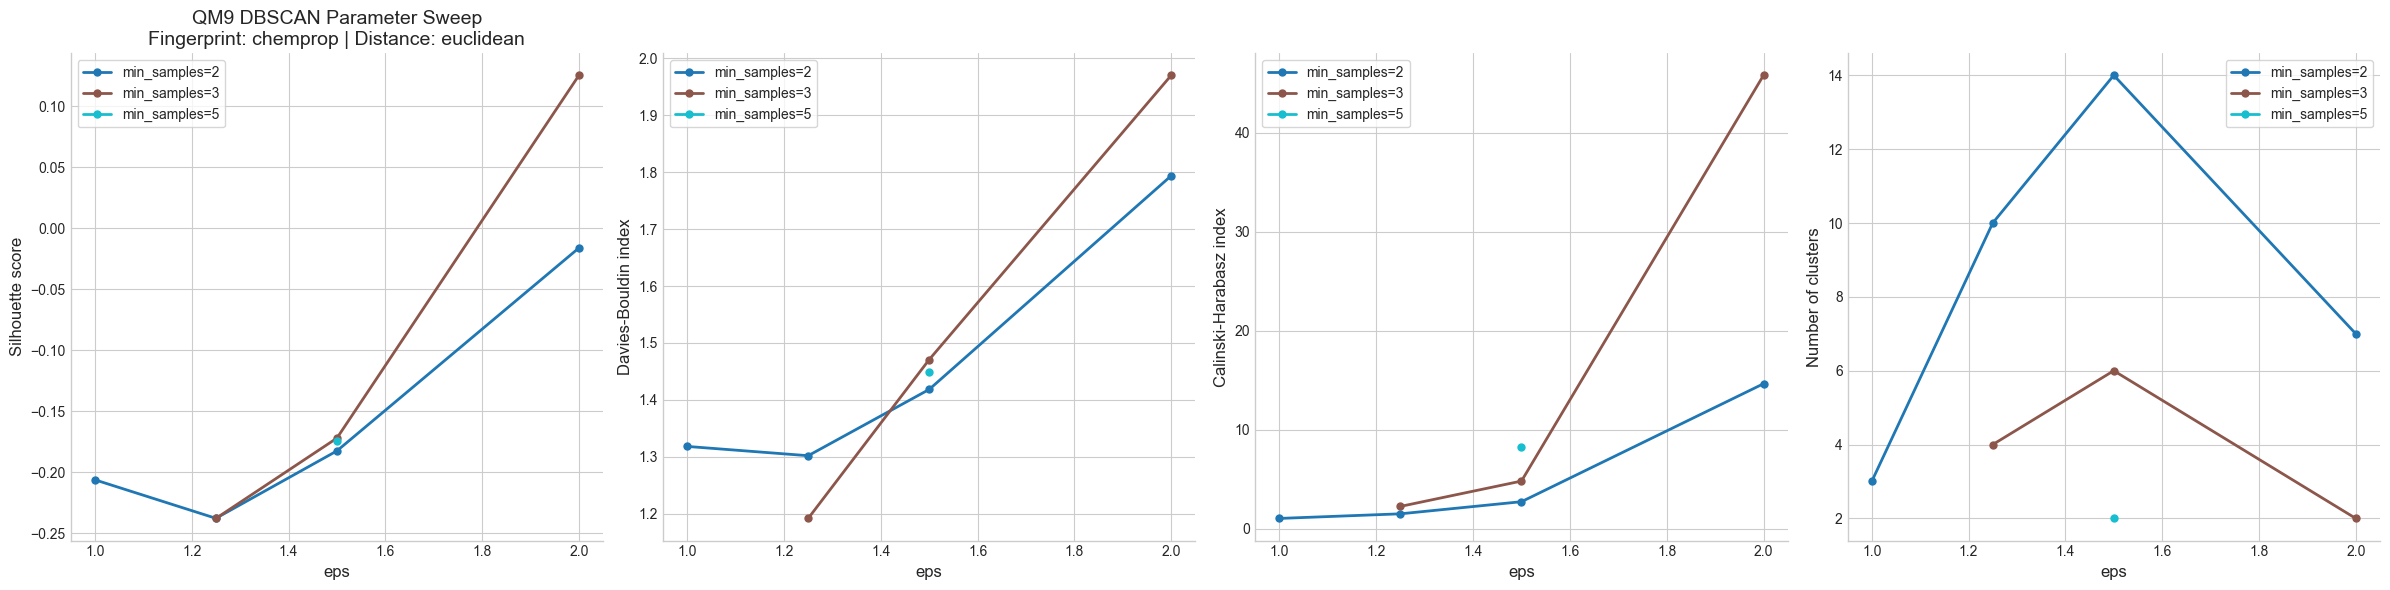

2026-04-28 21:22:49.348 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:985 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.png
2026-04-28 21:22:49.348 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:987 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/chemprop/dbscan_parameter_sweep.png
2026-04-28 21:22:49.348 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:988 - Saved clustering sweep results to figures/qm9/clustering/euclidean/chemprop/clustering_sweep_2_to_20_clusters.json


In [10]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [11]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(136), np.int64(137)), (np.int64(154), np.int64(179)), (np.int64(233), np.int64(234)), (np.int64(227), np.int64(228)), (np.int64(154), np.int64(212)), (np.int64(205), np.int64(206)), (np.int64(99), np.int64(185)), (np.int64(179), np.int64(212)), (np.int64(101), np.int64(102)), (np.int64(170), np.int64(176))]


In [12]:
print(mols[0])

(Atoms(symbols='C5OCOCH12', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='C3OC4OH12', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [13]:
plot_molecules_with_py3dmol(mols[5])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

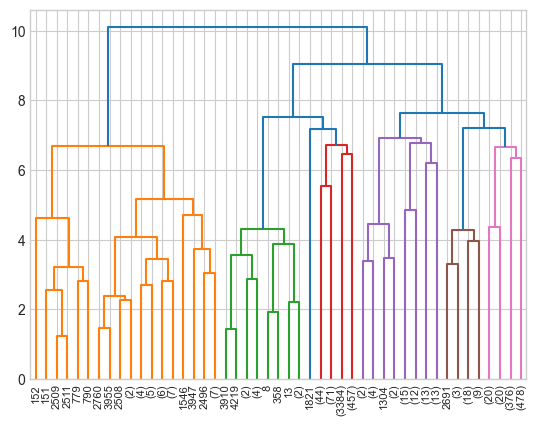

In [42]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [43]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2, 3]), array([3970,   62,  925,   43]))


In [44]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-04-28 21:26:19.496 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:26:19.496 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:26:40.907 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:26:40.910 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:26:41.145 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:26:41.214 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

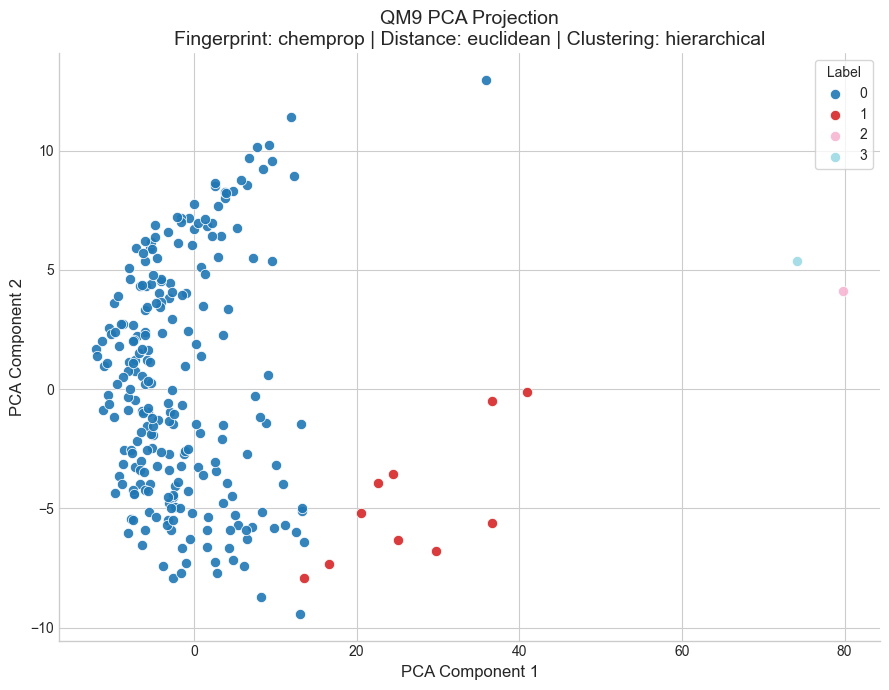

2026-04-28 21:22:50.624 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hierarchical_projection.png


{'coords': array([[ 3.86213246e+00,  8.00344405e+00],
        [ 6.56393521e+00, -2.72085329e+00],
        [-5.75046272e+00,  1.22052038e+00],
        [-4.10397355e-02,  6.69995928e+00],
        [-5.90598397e+00,  4.32928532e+00],
        [ 3.53227415e+00,  2.27681139e+00],
        [ 7.52084685e+00, -2.71621023e-01],
        [-5.07868057e+00, -1.93367650e+00],
        [-1.56920449e+00, -3.20720487e+00],
        [ 6.49848901e+00,  8.57428816e+00],
        [-9.89606332e-01,  4.01043573e+00],
        [-9.19177061e+00,  1.80137970e+00],
        [-7.22656090e-01, -4.28449116e+00],
        [-2.98290805e+00,  4.44053689e+00],
        [-1.04210771e+01,  2.56055485e+00],
        [-1.12423858e+01, -8.85220743e-01],
        [ 5.37195460e+00, -5.71776471e+00],
        [-3.11781296e+00,  3.82905060e+00],
        [-2.57139183e+00, -4.50739195e+00],
        [ 1.33072270e+01, -5.10542411e+00],
        [-3.11040701e+00, -4.78913806e+00],
        [ 2.97411033e+01, -6.80645497e+00],
        [-7.03610616e+

In [17]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [18]:
average_numeric_by_cluster(df, "labels_hier")

shape: (4, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,238,2.031017,0.0,123.630252,0.142857,38.567227,0.861861,12.850113,8.840336,1.5,0.176471,0.016807,2.512605,18.319328,2.047047,2.432773,0.075375,0.238102,0.686523,0.886555,2.117647,6.382353,0.491597,1.336134,4.5,6.453782,37.584034,1.262082,0.0,0.327731,0.046218,0.121849,0.12605,0.0,0.042017,0.147059,0.542017,0.0,2.811415,75.574664,-6.55847,0.254426,6.812988,1237.700833,4.088208,-11297.195177,-11296.95896,-11296.933243,-11298.114168,32.180231,-76.643688,-77.107618,-77.548874,-71.329382,3.321515,1.33542,1.06668,72.268908,17.226891,10.504202,37.584034,149,"""Acyclic""",10.504202,71,"""C1CCCC1""",14.705882,1,null,0.0
1,10,2.220967,0.0,120.1,-0.4,27.0,0.897381,12.714598,8.8,4.1,0.0,0.0,1.8,17.7,2.285286,1.5,0.026786,0.033333,0.939881,1.2,1.4,7.4,0.2,0.2,6.6,5.6,39.3,1.285375,0.0,0.6,0.0,0.0,0.1,0.0,0.0,0.1,0.2,0.0,2.3133,73.666,-6.482296,1.350229,7.832253,966.520422,3.871595,-10631.256836,-10631.057129,-10631.031543,-10632.115918,29.1164,-74.28896,-74.759972,-75.181474,-69.150191,3.451665,1.640747,1.439295,100.0,0.0,0.0,39.3,9,"""C1C2C3C1C1C2C31""",20.0,8,"""C1C2C3CC2C13""",20.0,1,null,0.0
2,1,2.263158,0.0,124.0,-1.0,16.0,0.865152,12.787292,9.0,6.0,0.0,0.0,2.0,19.0,2.315789,1.0,0.0,0.0,1.0,1.0,1.0,8.0,0.0,0.0,7.0,6.0,43.0,1.273056,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.8553,76.870003,-6.383791,1.869422,8.255935,1030.793579,4.00021,-10934.143555,-10933.94043,-10933.915039,-10935.003906,29.83,-74.670036,-75.160332,-75.597267,-69.335052,3.22571,1.59092,1.24487,100.0,0.0,0.0,43.0,1,"""C1C2C3[NH+]1C2C31CO1""",100.0,1,"""C1C2C3C1C2C31CC1""",100.0,1,null,0.0
3,1,2.238095,0.0,126.0,-1.0,24.0,0.854585,12.864544,9.0,5.0,0.0,0.0,2.0,21.0,2.190476,3.0,0.0,0.0,1.0,2.0,1.0,8.0,0.0,0.0,7.0,7.0,47.0,1.252036,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.7399,79.489998,-6.536175,1.899355,8.438251,1190.839844,4.636956,-10967.741211,-10967.511719,-10967.485352,-10968.638672,32.839001,-81.041801,-81.58255,-82.070908,-75.16333,3.07633,1.31632,1.08154,100.0,0.0,0.0,47.0,1,"""C1C2C3C[NH+]2C13""",100.0,1,"""C1C2C3CC2C13""",100.0,1,null,0.0


# KMedoids

In [19]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-04-28 21:22:50.718 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:22:50.719 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:22:51.537 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:22:51.539 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:22:51.552 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:22:51.556 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

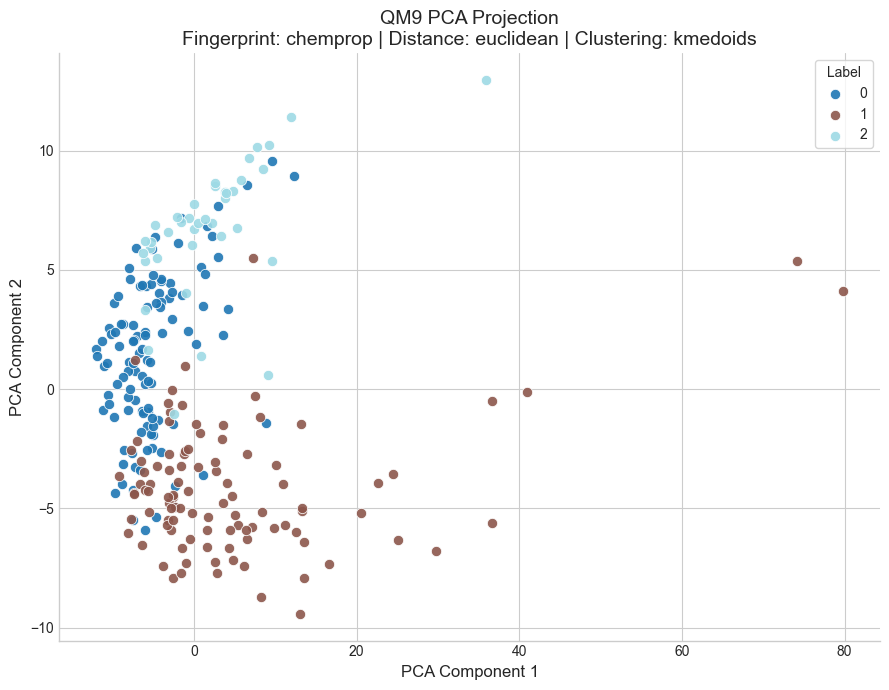

2026-04-28 21:22:51.815 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_kmedoids_projection.png


{'coords': array([[ 3.86213246e+00,  8.00344405e+00],
        [ 6.56393521e+00, -2.72085329e+00],
        [-5.75046272e+00,  1.22052038e+00],
        [-4.10397355e-02,  6.69995928e+00],
        [-5.90598397e+00,  4.32928532e+00],
        [ 3.53227415e+00,  2.27681139e+00],
        [ 7.52084685e+00, -2.71621023e-01],
        [-5.07868057e+00, -1.93367650e+00],
        [-1.56920449e+00, -3.20720487e+00],
        [ 6.49848901e+00,  8.57428816e+00],
        [-9.89606332e-01,  4.01043573e+00],
        [-9.19177061e+00,  1.80137970e+00],
        [-7.22656090e-01, -4.28449116e+00],
        [-2.98290805e+00,  4.44053689e+00],
        [-1.04210771e+01,  2.56055485e+00],
        [-1.12423858e+01, -8.85220743e-01],
        [ 5.37195460e+00, -5.71776471e+00],
        [-3.11781296e+00,  3.82905060e+00],
        [-2.57139183e+00, -4.50739195e+00],
        [ 1.33072270e+01, -5.10542411e+00],
        [-3.11040701e+00, -4.78913806e+00],
        [ 2.97411033e+01, -6.80645497e+00],
        [-7.03610616e+

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [22]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,110,2.034055,0.0,124.545455,0.254545,36.954545,0.890205,12.83388,8.890909,0.990909,0.090909,0.009091,2.372727,18.936364,1.997224,2.845455,0.103084,0.216068,0.680848,0.736364,1.981818,6.272727,0.709091,1.354545,4.454545,6.881818,38.745455,1.25422,0.0,0.281818,0.009091,0.090909,0.181818,0.0,0.045455,0.163636,0.545455,0.0,2.947596,77.732818,-6.675077,0.038046,6.713247,1381.242609,4.261946,-11303.066442,-11302.814693,-11302.78892,-11304.013512,33.557445,-79.049021,-79.521422,-79.978693,-73.578787,3.344309,1.16098,0.916465,0.0,69.090909,9.090909,21.818182,38.745455,59,"""Acyclic""",21.818182,28,"""Acyclic""",21.818182,1,null,0.0
1,101,2.146859,0.0,123.009901,0.019802,29.990099,0.920682,12.781432,8.841584,2.554455,0.009901,0.0,2.039604,18.821782,2.142923,1.861386,0.036127,0.090484,0.873389,0.831683,1.792079,7.0,0.237624,0.594059,5.970297,5.861386,40.564356,1.275257,0.0,0.415842,0.0,0.009901,0.079208,0.0,0.039604,0.178218,0.623762,0.0,2.517916,75.214356,-6.570526,0.856027,7.42658,1077.729572,4.249494,-11040.9889,-11040.767153,-11040.741448,-11041.877814,31.421129,-78.437291,-78.934019,-79.387501,-72.961052,2.996703,1.531163,1.289471,0.148515,99.009901,0.990099,0.0,40.564356,86,"""C1CC1""",5.940594,59,"""C1CC2CC12""",8.910891,1,null,0.0
2,39,1.782417,0.0,121.820513,-0.051282,61.410256,0.638593,13.037778,8.692308,1.076923,0.794872,0.076923,3.923077,15.205128,2.010933,2.487179,0.08254,0.617827,0.299634,1.564103,3.102564,5.435897,0.435897,2.846154,1.487179,6.564103,27.410256,1.256135,0.0,0.307692,0.25641,0.461538,0.076923,0.0,0.025641,0.0,0.230769,0.0,2.982046,70.064872,-6.173775,-0.3287,5.845285,1171.083646,3.136759,-11755.633789,-11755.414288,-11755.388722,-11756.534054,29.432692,-64.672832,-65.032395,-65.39285,-60.247701,4.123034,1.404855,1.013886,0.0,20.512821,76.923077,2.564103,27.410256,27,"""c1cnoc1""",7.692308,9,"""C1CCCC1""",56.410256,1,null,0.0


# Spectral

In [23]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

In [24]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

2026-04-28 21:22:51.955 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:22:51.956 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:22:52.818 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:22:52.820 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:22:52.835 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:22:52.839 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

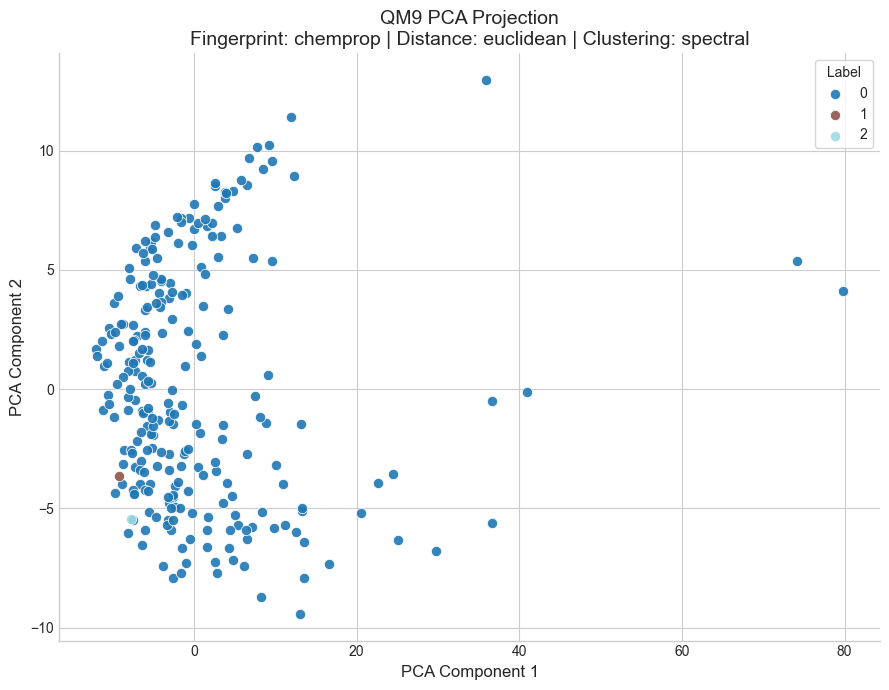

2026-04-28 21:22:53.084 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_spectral_projection.png


{'coords': array([[ 3.86213246e+00,  8.00344405e+00],
        [ 6.56393521e+00, -2.72085329e+00],
        [-5.75046272e+00,  1.22052038e+00],
        [-4.10397355e-02,  6.69995928e+00],
        [-5.90598397e+00,  4.32928532e+00],
        [ 3.53227415e+00,  2.27681139e+00],
        [ 7.52084685e+00, -2.71621023e-01],
        [-5.07868057e+00, -1.93367650e+00],
        [-1.56920449e+00, -3.20720487e+00],
        [ 6.49848901e+00,  8.57428816e+00],
        [-9.89606332e-01,  4.01043573e+00],
        [-9.19177061e+00,  1.80137970e+00],
        [-7.22656090e-01, -4.28449116e+00],
        [-2.98290805e+00,  4.44053689e+00],
        [-1.04210771e+01,  2.56055485e+00],
        [-1.12423858e+01, -8.85220743e-01],
        [ 5.37195460e+00, -5.71776471e+00],
        [-3.11781296e+00,  3.82905060e+00],
        [-2.57139183e+00, -4.50739195e+00],
        [ 1.33072270e+01, -5.10542411e+00],
        [-3.11040701e+00, -4.78913806e+00],
        [ 2.97411033e+01, -6.80645497e+00],
        [-7.03610616e+

In [25]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [26]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,248,2.039162,0.0,123.479839,0.108871,38.120968,0.862276,12.845142,8.83871,1.629032,0.169355,0.016129,2.487903,18.28629,2.057927,2.403226,0.073416,0.229341,0.697243,0.91129,2.084677,6.427419,0.479839,1.28629,4.584677,6.423387,37.645161,1.262976,0.0,0.342742,0.044355,0.116935,0.125,0.0,0.040323,0.141129,0.524194,0.0,2.786224,75.489839,-6.556177,0.305503,6.861779,1227.441007,4.073731,-11269.631946,-11269.397185,-11269.37147,-11270.548619,32.052101,-76.468193,-76.931765,-77.371809,-71.165677,3.333081,1.345472,1.079243,0.060484,0.71371,73.387097,16.532258,10.080645,37.645161,157,"""Acyclic""",10.080645,77,"""C1CCCC1""",14.112903,1,null,0.0
1,1,2.142857,0.0,128.0,0.0,18.0,0.990829,12.820921,9.0,2.0,0.0,0.0,2.0,21.0,2.095238,1.0,0.0,0.0,1.0,0.0,2.0,7.0,0.0,0.0,7.0,6.0,45.0,1.264378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.8362,76.980003,-6.517127,2.22317,8.740297,1000.458191,5.032365,-11544.308594,-11544.099609,-11544.074219,-11545.164062,31.608999,-86.686775,-87.287933,-87.80201,-80.479645,2.53628,1.79855,1.48167,0.0,1.0,100.0,0.0,0.0,45.0,1,"""C1CC2CC(CO2)O1""",100.0,1,"""C1CC2CCC(C1)C2""",100.0,1,null,0.0
2,1,2.238095,0.0,124.0,1.0,17.0,0.981353,12.708646,9.0,3.0,0.0,0.0,1.0,21.0,2.095238,1.0,0.0,0.125,0.875,0.0,1.0,8.0,0.0,1.0,7.0,6.0,47.0,1.271949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0251,81.330002,-6.209638,-0.163268,6.04637,1053.807983,5.028855,-10533.874023,-10533.654297,-10533.628906,-10534.751953,32.198002,-89.00061,-89.590179,-90.104256,-82.825592,2.19907,1.66912,1.45527,0.0,1.0,100.0,0.0,0.0,47.0,1,"""O=C1C2CCCC1C2""",100.0,1,"""CC1C2CCCC1C2""",100.0,1,null,0.0


# DBSCAN 

In [27]:
model_db = DBSCAN(
    eps=0.08,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1]), array([250]))


In [28]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-04-28 21:22:53.130 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:22:53.131 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:22:53.910 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:22:53.912 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:22:53.925 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:22:53.930 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

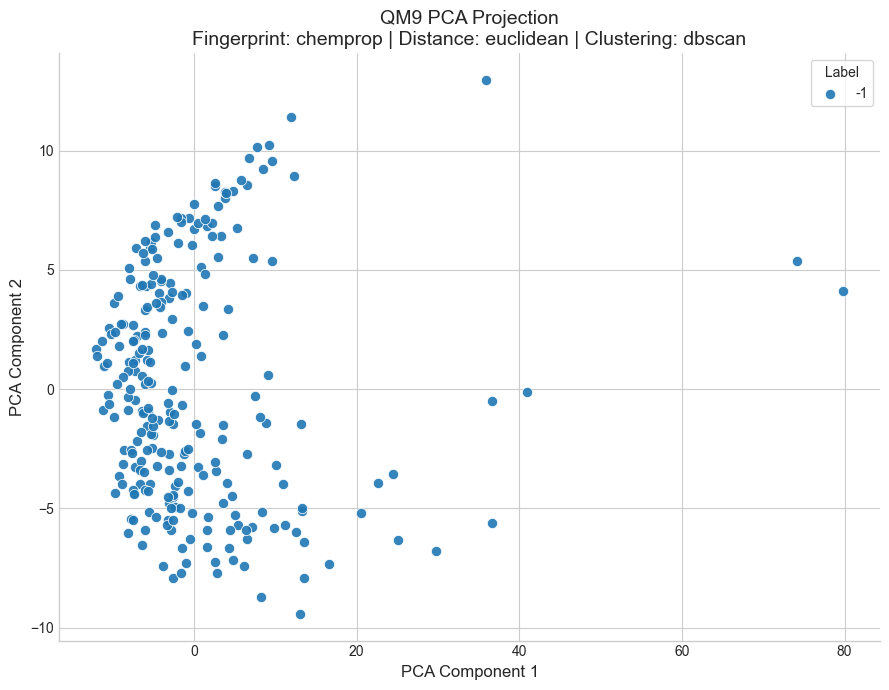

2026-04-28 21:22:54.130 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_dbscan_projection.png


{'coords': array([[ 3.86213246e+00,  8.00344405e+00],
        [ 6.56393521e+00, -2.72085329e+00],
        [-5.75046272e+00,  1.22052038e+00],
        [-4.10397355e-02,  6.69995928e+00],
        [-5.90598397e+00,  4.32928532e+00],
        [ 3.53227415e+00,  2.27681139e+00],
        [ 7.52084685e+00, -2.71621023e-01],
        [-5.07868057e+00, -1.93367650e+00],
        [-1.56920449e+00, -3.20720487e+00],
        [ 6.49848901e+00,  8.57428816e+00],
        [-9.89606332e-01,  4.01043573e+00],
        [-9.19177061e+00,  1.80137970e+00],
        [-7.22656090e-01, -4.28449116e+00],
        [-2.98290805e+00,  4.44053689e+00],
        [-1.04210771e+01,  2.56055485e+00],
        [-1.12423858e+01, -8.85220743e-01],
        [ 5.37195460e+00, -5.71776471e+00],
        [-3.11781296e+00,  3.82905060e+00],
        [-2.57139183e+00, -4.50739195e+00],
        [ 1.33072270e+01, -5.10542411e+00],
        [-3.11040701e+00, -4.78913806e+00],
        [ 2.97411033e+01, -6.80645497e+00],
        [-7.03610616e+

In [29]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [30]:
average_numeric_by_cluster(df, "labels_db")

shape: (1, 74)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,250,2.040372,0.0,123.5,0.112,37.956,0.863266,12.844499,8.84,1.636,0.168,0.016,2.48,18.308,2.058225,2.392,0.072829,0.228006,0.699165,0.904,2.08,6.436,0.476,1.28,4.604,6.42,37.712,1.263018,0.0,0.34,0.044,0.116,0.124,0.0,0.04,0.144,0.528,0.0,2.77938,75.51916,-6.554635,0.311298,6.866031,1225.838544,4.081386,-11267.787621,-11267.553023,-11267.527311,-11268.703895,32.050912,-76.559197,-77.023823,-77.46446,-71.249573,3.325358,1.348579,1.082357,0.06,0.716,0.012,73.6,16.4,10.0,37.712,159,"""Acyclic""",10.0,78,"""C1CCCC1""",14.0,1,null,0.0


# HDBSCAN

In [31]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:



In [32]:
clusterer = HDBSCAN(
        min_cluster_size=60,
        min_samples=6,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [33]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-04-28 21:22:54.505 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:22:54.507 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:22:55.191 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:22:55.193 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:22:55.205 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:22:55.210 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

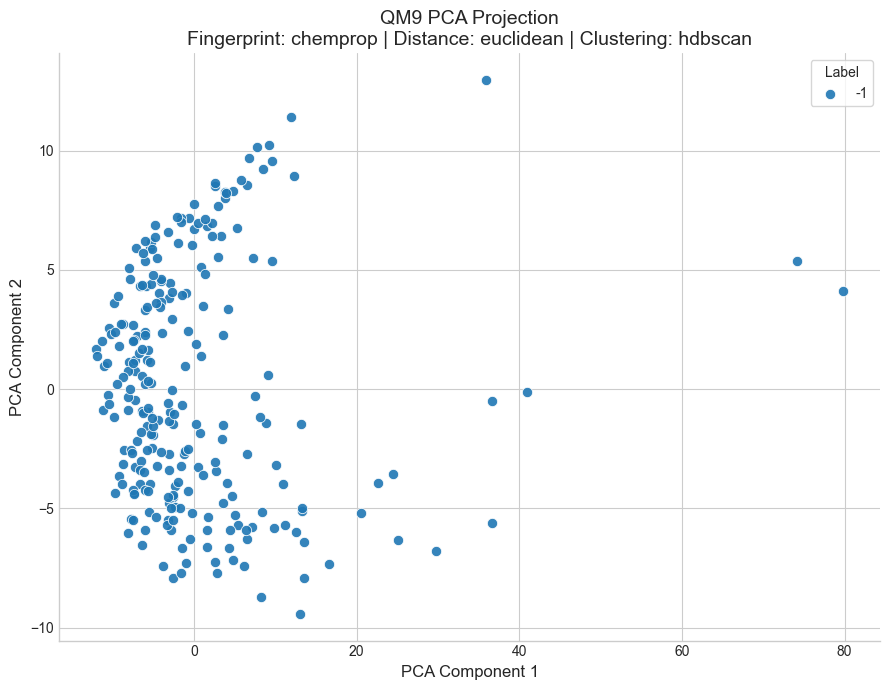

2026-04-28 21:22:55.406 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/euclidean/chemprop/pca_hdbscan_projection.png


{'coords': array([[ 3.86213246e+00,  8.00344405e+00],
        [ 6.56393521e+00, -2.72085329e+00],
        [-5.75046272e+00,  1.22052038e+00],
        [-4.10397355e-02,  6.69995928e+00],
        [-5.90598397e+00,  4.32928532e+00],
        [ 3.53227415e+00,  2.27681139e+00],
        [ 7.52084685e+00, -2.71621023e-01],
        [-5.07868057e+00, -1.93367650e+00],
        [-1.56920449e+00, -3.20720487e+00],
        [ 6.49848901e+00,  8.57428816e+00],
        [-9.89606332e-01,  4.01043573e+00],
        [-9.19177061e+00,  1.80137970e+00],
        [-7.22656090e-01, -4.28449116e+00],
        [-2.98290805e+00,  4.44053689e+00],
        [-1.04210771e+01,  2.56055485e+00],
        [-1.12423858e+01, -8.85220743e-01],
        [ 5.37195460e+00, -5.71776471e+00],
        [-3.11781296e+00,  3.82905060e+00],
        [-2.57139183e+00, -4.50739195e+00],
        [ 1.33072270e+01, -5.10542411e+00],
        [-3.11040701e+00, -4.78913806e+00],
        [ 2.97411033e+01, -6.80645497e+00],
        [-7.03610616e+

In [34]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="chemprop",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [35]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (1, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,250,2.040372,0.0,123.5,0.112,37.956,0.863266,12.844499,8.84,1.636,0.168,0.016,2.48,18.308,2.058225,2.392,0.072829,0.228006,0.699165,0.904,2.08,6.436,0.476,1.28,4.604,6.42,37.712,1.263018,0.0,0.34,0.044,0.116,0.124,0.0,0.04,0.144,0.528,0.0,2.77938,75.51916,-6.554635,0.311298,6.866031,1225.838544,4.081386,-11267.787621,-11267.553023,-11267.527311,-11268.703895,32.050912,-76.559197,-77.023823,-77.46446,-71.249573,3.325358,1.348579,1.082357,0.06,0.716,0.012,-1.0,73.6,16.4,10.0,37.712,159,"""Acyclic""",10.0,78,"""C1CCCC1""",14.0,1,null,0.0


# KMeans on Raw Embeddings


In [36]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA

X = np.array(df['chemprop_embedding'].to_list())
pca = PCA(n_components=4)
X = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([ 21, 119, 110]))


In [37]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,21,2.211443,0.0,121.714286,-0.714286,29.714286,0.865211,12.767729,8.857143,3.857143,0.0,0.0,2.047619,18.095238,2.260531,1.380952,0.035431,0.022676,0.941893,1.428571,1.47619,7.333333,0.238095,0.142857,6.428571,5.809524,40.047619,1.282719,0.0,0.666667,0.0,0.0,0.047619,0.0,0.0,0.095238,…,2.72549,73.668571,-6.369408,1.254574,7.623982,984.620765,3.922852,-10831.232608,-10831.032552,-10831.006882,-10832.090634,29.343381,-74.545656,-75.022878,-75.448789,-69.346863,3.357952,1.630992,1.408695,0.714286,1.0,0.0,-1.0,-1.0,100.0,0.0,0.0,40.047619,19,"""C1C2C3C1C1C2C31""",9.52381,16,"""C1C2C3CC2C13""",14.285714,1,null,0.0
1,119,2.129529,0.0,124.134454,0.260504,29.991597,0.932865,12.798055,8.87395,2.0,0.016807,0.0,2.016807,19.462185,2.093334,2.226891,0.033063,0.121852,0.845085,0.731092,1.831933,6.957983,0.235294,0.815126,5.806723,6.226891,41.588235,1.268996,0.0,0.394958,0.0,0.008403,0.07563,0.0,0.042017,0.184874,…,2.486071,77.016639,-6.587533,0.657166,7.244814,1189.563296,4.465568,-11124.119411,-11123.885578,-11123.859814,-11125.028722,32.608328,-80.878789,-81.391059,-81.862997,-75.211883,3.038934,1.387496,1.154573,0.0,0.680672,0.02521,-1.0,-1.0,98.319328,1.680672,0.0,41.588235,91,"""C1CC1""",10.92437,56,"""C1CC1""",17.647059,1,null,0.0
2,110,1.911262,0.0,123.154545,0.109091,48.145455,0.787601,12.9094,8.8,0.818182,0.363636,0.036364,3.063636,17.1,1.981621,2.763636,0.122987,0.382045,0.494968,0.990909,2.463636,5.7,0.781818,2.0,2.954545,6.745455,33.072727,1.25279,0.0,0.218182,0.1,0.254545,0.190909,0.0,0.045455,0.109091,…,3.106974,74.252454,-6.554406,-0.242948,6.311557,1311.132434,3.696037,-11506.552823,-11506.310804,-11506.285138,-11507.487749,31.964782,-72.270586,-72.681267,-73.090851,-67.326318,3.628993,1.252562,0.941932,0.0,0.7,0.0,-1.0,-1.0,41.818182,35.454545,22.727273,33.072727,57,"""Acyclic""",22.727273,13,"""C1CCCC1""",30.0,1,null,0.0


In [38]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-04-28 21:22:55.592 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-28 21:22:55.637 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-28 21:22:56.415 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-28 21:22:56.417 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-28 21:22:56.430 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-28 21:22:56.434 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…